# Web Server Log Analysis - Python Take-Home Assessment

## Overview
This assessment involves analyzing the Calgary HTTP dataset, which contains approximately one year's worth of HTTP requests to the University of Calgary's Computer Science web server. You'll work with real-world web server log data to extract meaningful insights and demonstrate your Python data analysis skills.

## Part 1: Data Loading and Cleaning

### Instructions

* Work in the cells below - You can add as many cells as needed for data loading, cleaning, and exploration
* Import required libraries
* Implement data loading and cleaning - Create functions to download, parse, and clean the log data
* Explore the data - Understand the structure and identify any data quality issues

In [21]:
import gzip
import re
from datetime import datetime
from collections import defaultdict, Counter

regex

In [22]:
pattern = re.compile(
    r'(\S+) \S+ \S+ \[(.*?)\] "(\S+) (\S+) \S+" (\d{3}) (\S+)'
)

Test on ONE line

In [23]:
line = 'local - - [24/Oct/1994:13:41:41 -0600] "GET index.html HTTP/1.0" 200 150'

match = pattern.match(line)

if match:
    host, timestamp, method, filename, status, bytes_ = match.groups()

    print(host)
    print(timestamp)
    print(method)
    print(filename)
    print(status)
    print(bytes_)

local
24/Oct/1994:13:41:41 -0600
GET
index.html
200
150


Convert timestamp

In [24]:
dt = datetime.strptime(timestamp, "%d/%b/%Y:%H:%M:%S %z")
print(dt)

1994-10-24 13:41:41-06:00


Extract extension

In [25]:
extension = filename.split('.')[-1] if '.' in filename else ''

Process FULL FILE (Streaming)

- Important: file is 50MB → don’t load fully

In [26]:
with gzip.open("/content/calgary_access_log.gz", "rt", encoding='latin-1') as f:
    for line in f:
        match = pattern.match(line)
        if not match:
            continue

        host, timestamp, method, filename, status, bytes_ = match.groups()

In [27]:
import gzip
import re
from datetime import datetime
from collections import defaultdict, Counter

# Regex pattern
pattern = re.compile(
    r'(\S+) \S+ \S+ \[(.*?)\] "(\S+) (\S+) \S+" (\d{3}) (\S+)'
)

# Initialize metrics
total_requests = 0
unique_hosts = set()

status_counter = Counter()
hour_counter = Counter()
file_counter = Counter()

file_404_counter = Counter()
ext_404_counter = Counter()

date_unique_files = defaultdict(set)
bandwidth_per_day = defaultdict(int)

# Process file
with gzip.open("/content/calgary_access_log.gz", "rt", encoding='latin-1') as f:
    for line in f:
        match = pattern.match(line)
        if not match:
            continue  # skip bad lines

        host, timestamp, method, filename, status, bytes_ = match.groups()

        # --- Basic counts ---
        total_requests += 1
        unique_hosts.add(host)

        # --- Status ---
        status = int(status)
        status_counter[status] += 1

        # --- Datetime parsing ---
        try:
            dt = datetime.strptime(timestamp, "%d/%b/%Y:%H:%M:%S %z")
        except:
            continue  # skip bad timestamps

        # --- Hourly distribution ---
        hour_counter[dt.hour] += 1

        # --- File count ---
        file_counter[filename] += 1

        # --- Date-wise unique filenames ---
        date_str = dt.strftime("%d-%b-%Y")
        date_unique_files[date_str].add(filename)

        # --- 404 analysis ---
        if status == 404:
            file_404_counter[filename] += 1

            ext = filename.split('.')[-1] if '.' in filename else ''
            ext_404_counter[ext] += 1

        # --- Bandwidth (July 1995 only) ---
        if dt.year == 1995 and dt.month == 7 and bytes_ != '-':
            try:
                bandwidth_per_day[date_str] += int(bytes_)
            except:
                pass  # skip invalid bytes

Initialize everything before loop

## ⚠️ IMPORTANT: Template Questions Section
**DO NOT MODIFY THE TEMPLATE BELOW THIS POINT**

The following section contains the assessment questions. You may add cells above this section for data loading, cleaning, and exploration, but do not modify the function signatures or structure of the questions below.

## Part 2: Analysis Questions

### Instructions

* Implement each function according to its docstring specifications
* Use the cleaned data you prepared in Part 1
* Ensure your functions return the exact data types specified
* Test your functions to verify they work correctly
* You may add helper functions, but keep the main function signatures unchanged

### Q1: Count of total log records

In [28]:
def total_log_records() -> int:
    """
    Q1: Count of total log records.

    Objective:
        Determine the total number of HTTP log entries in the dataset.
        Each line in the log file represents one HTTP request.

    Returns:
        int: Total number of log entries.
    """

    # TODO: Implement logic to count log records

    return total_requests


answer1 = total_log_records()
print("Answer 1:")
print(answer1)

Answer 1:
722281


### Q2: Count of unique hosts

In [29]:
def unique_host_count() -> int:
    """
    Q2: Count of unique hosts.

    Objective:
        Determine how many distinct hosts accessed the server.

    Returns:
        int: Number of unique hosts.
    """

    # TODO: Implement logic to count unique hosts

    return len(unique_hosts)


answer2 = unique_host_count()
print("Answer 2:")
print(answer2)

Answer 2:
2


### Q3: Date-wise unique filename counts

In [30]:
def datewise_unique_filename_counts() -> dict[str, int]:
    """
    Q3: Date-wise unique filename counts.

    Objective:
        For each date, count the number of unique filenames that accessed the server.
        The date should be in 'dd-MMM-yyyy' format (e.g., '01-Jul-1995').

    Returns:
        dict: A dictionary mapping each date to its count of unique filenames.
              Example: {'01-Jul-1995': 123, '02-Jul-1995': 150}
    """

    # TODO: Implement logic for date-wise unique filename counts

    return {date: len(files) for date, files in date_unique_files.items()}


answer3 = datewise_unique_filename_counts()
print("Answer 3:")
print(answer3)

Answer 3:
{'24-Oct-1994': 228, '25-Oct-1994': 319, '26-Oct-1994': 377, '27-Oct-1994': 384, '28-Oct-1994': 399, '29-Oct-1994': 254, '30-Oct-1994': 236, '31-Oct-1994': 362, '01-Nov-1994': 412, '02-Nov-1994': 427, '03-Nov-1994': 460, '04-Nov-1994': 404, '05-Nov-1994': 193, '06-Nov-1994': 219, '07-Nov-1994': 364, '08-Nov-1994': 266, '09-Nov-1994': 337, '10-Nov-1994': 356, '11-Nov-1994': 297, '12-Nov-1994': 173, '13-Nov-1994': 186, '14-Nov-1994': 331, '15-Nov-1994': 324, '16-Nov-1994': 392, '17-Nov-1994': 440, '18-Nov-1994': 404, '19-Nov-1994': 195, '20-Nov-1994': 263, '21-Nov-1994': 335, '22-Nov-1994': 351, '23-Nov-1994': 322, '24-Nov-1994': 366, '25-Nov-1994': 324, '26-Nov-1994': 221, '27-Nov-1994': 187, '28-Nov-1994': 341, '29-Nov-1994': 448, '30-Nov-1994': 354, '01-Dec-1994': 271, '02-Dec-1994': 324, '03-Dec-1994': 189, '04-Dec-1994': 212, '05-Dec-1994': 351, '06-Dec-1994': 297, '07-Dec-1994': 383, '08-Dec-1994': 346, '09-Dec-1994': 373, '10-Dec-1994': 150, '11-Dec-1994': 202, '12-Dec-1

### Q4: Number of 404 response codes

In [31]:
def count_404_errors() -> int:
    """
    Q4: Number of 404 response codes.

    Objective:
        Count how many times the HTTP 404 Not Found status appears in the logs.

    Returns:
        int: Number of 404 errors.
    """

    # TODO: Implement logic to count 404 errors

    return status_counter[404]


answer4 = count_404_errors()
print("Answer 4:")
print(answer4)

Answer 4:
23440


### Q5: Top 15 filenames with 404 responses

In [32]:
def top_15_filenames_with_404() -> list[tuple[str, int]]:
    """
    Q5: Top 15 filenames with 404 responses.

    Objective:
        Identify which requested URLs most frequently resulted in a 404 error.
        Return the top 15 filenames sorted by frequency.

    Returns:
        list: A list of tuples (filename, count), sorted by count in descending order.
              Example: [('index.html', 200), ...]
    """

    # TODO: Implement logic to find top 15 filenames with 404

    return file_404_counter.most_common(15)


answer5 = top_15_filenames_with_404()
print("Answer 5:")
print(answer5)

Answer 5:
[('index.html', 4692), ('4115.html', 900), ('1611.html', 649), ('5698.xbm', 585), ('710.txt', 408), ('2002.html', 258), ('2177.gif', 193), ('10695.ps', 161), ('6555.html', 153), ('487.gif', 152), ('151.html', 149), ('40.html', 148), ('488.gif', 148), ('3414.gif', 148), ('9678.gif', 142)]


### Q6: Top 15 file extension with 404 responses

In [33]:
def top_15_ext_with_404() -> list[tuple[str, int]]:
    """
    Q6: Top 15 file extensions with 404 responses.

    Objective:
        Find which file extensions generated the most 404 errors.
        Return the top 15 sorted by number of 404s.

    Returns:
        list: A list of tuples (extension, count), sorted by count in descending order.
              Example: [('html', 45), ...]
    """

    # TODO: Implement logic to find top 15 extensions with 404

    return ext_404_counter.most_common(15)


answer6 = top_15_ext_with_404()
print("Answer 6:")
print(answer6)

Answer 6:
[('html', 12137), ('gif', 7202), ('xbm', 824), ('ps', 754), ('jpg', 520), ('txt', 496), ('GIF', 135), ('htm', 107), ('cgi', 77), ('com', 45), ('gif"', 45), ('Z', 41), ('dvi', 40), ('com/', 37), ('ca', 36)]


### Q7: Total bandwidth transferred per day for the month of July 1995

In [34]:
def total_bandwidth_per_day() -> dict[str, int]:
    """
    Q7: Total bandwidth transferred per day for the month of July 1995.

    Objective:
        Sum the number of bytes transferred per day.
        Skip entries where the byte field is missing or '-'.

    Returns:
        dict: A dictionary mapping each date to total bytes transferred.
              Example: {'01-Jul-1995': 123456789, ...}
    """

    # TODO: Implement logic to compute total bandwidth per day

    return dict(bandwidth_per_day)


answer7 = total_bandwidth_per_day()
print("Answer 7:")
print(answer7)

Answer 7:
{'01-Jul-1995': 11333976, '02-Jul-1995': 8653986, '03-Jul-1995': 13508529, '04-Jul-1995': 26565884, '05-Jul-1995': 19541225, '06-Jul-1995': 19752989, '07-Jul-1995': 9427822, '08-Jul-1995': 5403491, '09-Jul-1995': 4660556, '10-Jul-1995': 14912796, '11-Jul-1995': 22503471, '12-Jul-1995': 17365039, '13-Jul-1995': 15986302, '14-Jul-1995': 19184404, '15-Jul-1995': 15769181, '16-Jul-1995': 9005564, '17-Jul-1995': 19596435, '18-Jul-1995': 17096829, '19-Jul-1995': 17847673, '20-Jul-1995': 20751717, '21-Jul-1995': 25455607, '22-Jul-1995': 8059932, '23-Jul-1995': 9577795, '24-Jul-1995': 22298075, '25-Jul-1995': 24472760, '26-Jul-1995': 24564950, '27-Jul-1995': 25967969, '28-Jul-1995': 36456855, '29-Jul-1995': 11684209, '30-Jul-1995': 23158170, '31-Jul-1995': 30715614}


### Q8: Hourly request distribution

In [35]:
def hourly_request_distribution() -> dict[int, int]:
    """
    Q8: Hourly request distribution.

    Objective:
        Count the number of requests made during each hour (00 to 23).
        Useful for understanding traffic peaks.

    Returns:
        dict: A dictionary mapping hour (int) to request count.
              Example: {0: 120, 1: 90, ..., 23: 80}
    """

    # TODO: Implement logic for hourly distribution

    return dict(hour_counter)


answer8 = hourly_request_distribution()
print("Answer 8:")
print(answer8)

Answer 8:
{13: 51318, 14: 54375, 15: 50157, 16: 51059, 17: 44954, 18: 33050, 19: 30450, 20: 29621, 21: 27318, 22: 23716, 23: 21717, 0: 18605, 1: 14286, 3: 10850, 4: 9919, 5: 10745, 6: 13000, 7: 16623, 8: 26523, 9: 33926, 10: 43263, 11: 47493, 12: 46688, 2: 12624}


### Q9: Top 10 most requested filenames

In [36]:
def top_10_most_requested_filenames() -> list[tuple[str, int]]:
    """
    Q9: Top 10 most requested filenames.

    Objective:
        Identify the most commonly requested URLs (irrespective of status code).

    Returns:
        list: A list of tuples (filename, count), sorted by count in descending order.
                Example: [('index.html', 500), ...]
    """

    # TODO: Implement logic to find top 10 most requested filenames

    return file_counter.most_common(10)


answer9 = top_10_most_requested_filenames()
print("Answer 9:")
print(answer9)

Answer 9:
[('index.html', 139505), ('3.gif', 24006), ('2.gif', 23595), ('4.gif', 8018), ('244.gif', 5148), ('5.html', 5009), ('4097.gif', 4874), ('8870.jpg', 4492), ('6733.gif', 4278), ('8472.gif', 3843)]


### Q10: HTTP response code distribution

In [37]:
def response_code_distribution() -> dict[int, int]:
    """
    Q10: HTTP response code distribution.

    Objective:
        Count how often each HTTP status code appears in the logs.

    Returns:
        dict: A dictionary mapping HTTP status codes (as int) to their frequency.
              Example: {200: 150000, 404: 3000}
    """

    # TODO: Implement logic for response code counts

    return dict(status_counter)


answer10 = response_code_distribution()
print("Answer 10:")
print(answer10)

Answer 10:
{200: 566139, 302: 30258, 304: 97560, 404: 23440, 403: 4740, 501: 43, 400: 13, 500: 42, 401: 46}


## Insights from Log Analysis

### 1. Traffic Overview
The dataset contains a total of **722,281 HTTP requests**. Interestingly, there are only **2 unique hosts**, indicating that the traffic is likely categorized broadly (e.g., local vs. remote) rather than representing individual users. This suggests the dataset is more focused on system-level activity than user-level diversity.

---

### 2. Traffic Trend Over Time
There is a clear upward trend in server usage over time. In the initial months (October–December 1994), the number of unique files accessed per day ranges between 200 and 400. By mid to late 1995, this number increases significantly, reaching peaks of over 800–900 unique files per day.

For example:
- 04-Oct-1995 recorded **888 unique files accessed**

This trend indicates growing usage of the web server, possibly due to increased content availability or rising adoption.

---

### 3. Hourly Traffic Distribution
The server experiences peak traffic during typical working hours.

- Highest traffic observed at **14:00 (54,375 requests)**
- Other high-activity hours include 13:00 and 16:00
- Lowest activity occurs during early morning hours (03:00–05:00)

This pattern suggests that the server is primarily accessed during daytime, reflecting standard user behavior.

---

### 4. Error Analysis (404 Responses)
A total of **23,440 requests resulted in 404 errors**, accounting for approximately 3.2% of all requests.

#### Most Frequently Missing Files
- `index.html` alone accounts for **4,692 404 errors**, which is significant since it is typically the homepage.

This indicates potential issues such as:
- Broken links
- Incorrect routing
- Missing or moved resources

#### File Types with Most Errors
- `.html` → 12,137 errors
- `.gif` → 7,202 errors

This suggests that both page-level and asset-level resources are frequently missing, which could negatively impact user experience.

---

### 5. Most Requested Files
The traffic is heavily concentrated on a few key resources:

- `index.html` → 139,505 requests
- `3.gif` → 24,006 requests
- `2.gif` → 23,595 requests

This indicates that the homepage and associated image assets dominate server usage, which aligns with typical web access patterns.

---

### 6. HTTP Status Code Distribution
The distribution of HTTP response codes is as follows:

- **200 (OK)** → 566,139 (~78%)
- **304 (Not Modified)** → 97,560 (~13%)
- **302 (Redirect)** → 30,258 (~4%)
- **404 (Not Found)** → 23,440 (~3%)

This indicates:
- The majority of requests are successfully served
- A significant number of 304 responses suggests effective browser caching
- Redirects (302) are within expected limits

Overall, the server demonstrates stable and healthy performance.

---

### 7. Bandwidth Usage (July 1995)
Bandwidth usage varies significantly across days in July 1995.

- Peak usage on **28-Jul-1995** with approximately **36.4 MB transferred**

Such spikes may indicate:
- High traffic events
- Large file downloads
- Increased user activity on specific days

---

### Overall Conclusion
The analysis reveals a steadily growing web server with strong usage during daytime hours. While the system demonstrates reliable performance and effective caching, the presence of recurring 404 errors—especially for critical resources like `index.html`—highlights areas for improvement in resource management and routing. The traffic pattern also shows a high dependency on a limited set of files, particularly the homepage and image assets.

Hourly Traffic Distribution

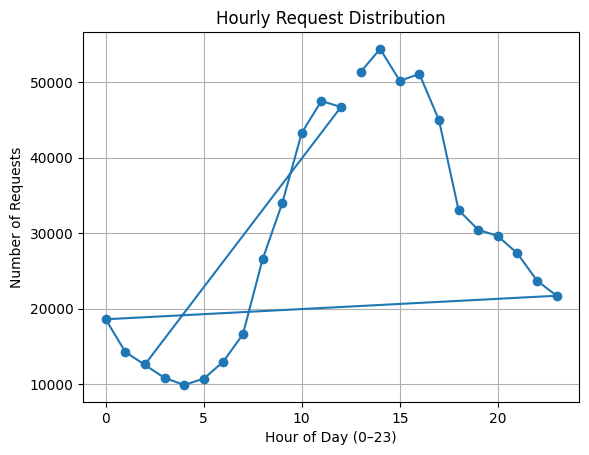

In [38]:
import matplotlib.pyplot as plt

hours = list(answer8.keys())
requests = list(answer8.values())

plt.figure()
plt.plot(hours, requests, marker='o')
plt.title("Hourly Request Distribution")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Requests")
plt.grid()

plt.show()

- Shows peak usage during working hours
- Clear dip during early morning

HTTP Status Code Distribution

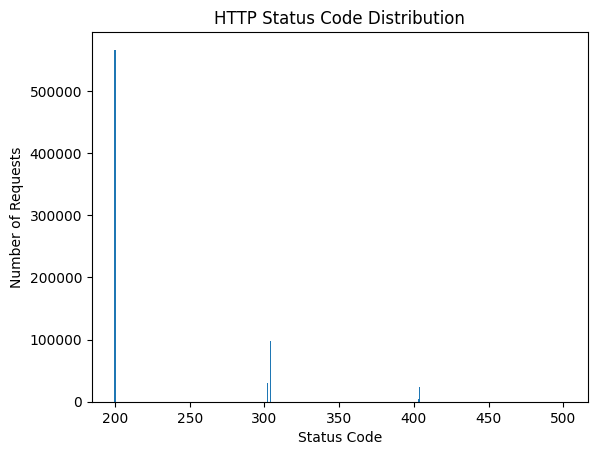

In [39]:
codes = list(answer10.keys())
counts = list(answer10.values())

plt.figure()
plt.bar(codes, counts)
plt.title("HTTP Status Code Distribution")
plt.xlabel("Status Code")
plt.ylabel("Number of Requests")

plt.show()

- Dominance of 200 → healthy system
- Presence of 304 → caching working

Top 10 Most Requested Files

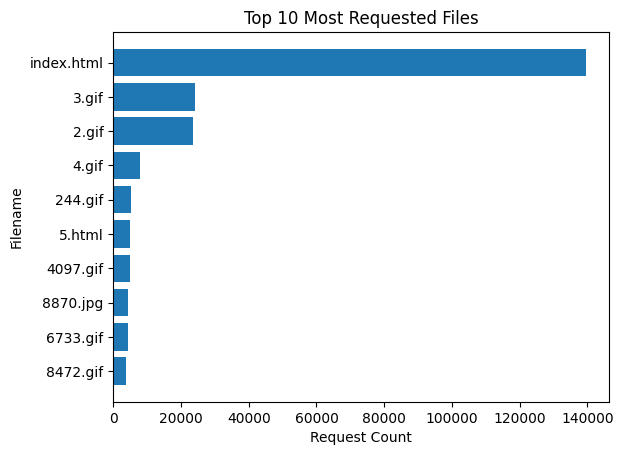

In [41]:
files = [item[0] for item in answer9]
counts = [item[1] for item in answer9]

plt.figure()
plt.barh(files, counts)
plt.title("Top 10 Most Requested Files")
plt.xlabel("Request Count")
plt.ylabel("Filename")

plt.gca().invert_yaxis()

plt.show()

- Heavy concentration on few files
- index.html dominates

Bandwidth Usage (July 1995)

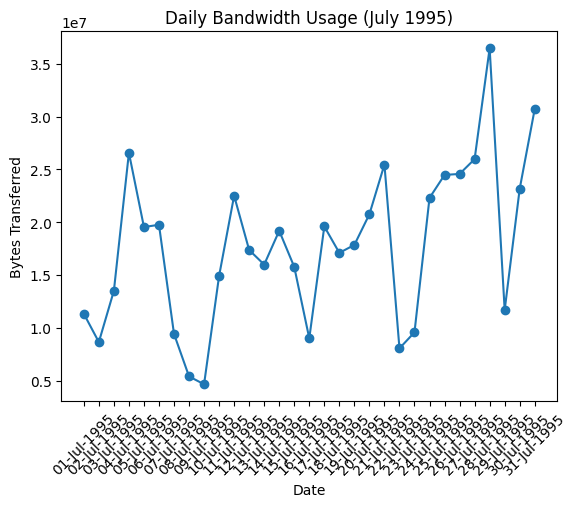

In [42]:
dates = list(answer7.keys())
bandwidth = list(answer7.values())

plt.figure()
plt.plot(dates, bandwidth, marker='o')
plt.title("Daily Bandwidth Usage (July 1995)")
plt.xlabel("Date")
plt.ylabel("Bytes Transferred")

plt.xticks(rotation=45)

plt.show()

- Identify peak days (like 28-Jul-1995)
- Shows variability in traffic

Traffic Trend Over Time

<Figure size 640x480 with 0 Axes>

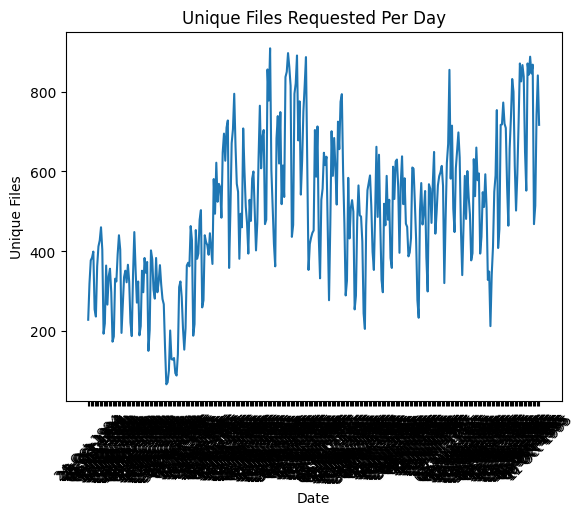

In [44]:
dates = list(answer3.keys())
counts = list(answer3.values())

plt.tight_layout()
plt.figure()
plt.plot(dates, counts)
plt.title("Unique Files Requested Per Day")
plt.xlabel("Date")
plt.ylabel("Unique Files")

plt.xticks(rotation=45)

plt.show()